# Convolutional neural networks

In class, we have briefly reviewed the idea of learning good features directly from data and went through the concept of convolutional neural networks along with few architectures.

Until recently, building convolutional neural networks was tough. There was no high-level tools for that, you would be required to understand all the internal mechanics of the model and its operations.

Today, due to the high-level tools such as Keras and TensorFlow, everybody can build a convolutional neural network and put it to work without diving deep into them. What used to be a one-month project became a few hours exercise.


In [3]:
import pickle
import numpy as np
import keras
import matplotlib.pyplot as plt

2026-03-20 13:34:55.799919: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Loading the images

In [4]:
train_images, train_labels = pickle.load(open('data/train_set_all.pkl', 'rb'))
cv_images, cv_labels = pickle.load(open('data/test_set_all.pkl', 'rb'))

In [5]:
print(train_images.shape)
print(len(train_labels))

(50000, 32, 32, 3)
50000


In [6]:
print(cv_images.shape)
print(len(cv_labels))

(10000, 32, 32, 3)
10000


In [7]:
print(train_labels[0:10])

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]


In [8]:
def show_image(np_array):
    %matplotlib inline
    plt.figure()
    plt.imshow(np_array)

In [9]:
def show_example(data_set, labels, example_index):
    show_image(data_set[example_index])
    print('Label: ', labels[example_index])

Label:  6


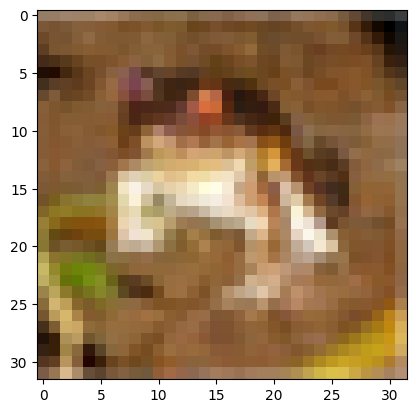

In [10]:
show_example(train_images, train_labels, example_index = 0)

Label:  3


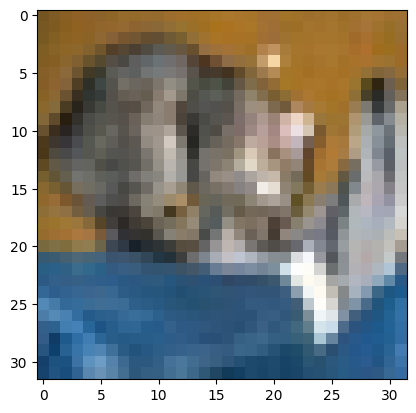

In [11]:
show_example(cv_images, cv_labels, example_index = 0)

## Building AlexNet

In 2012 a convolutional neural network called AlexNet won ImageNet competition. 

Go through an [original AlexNet paper](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf) to investigate the architecture. Next, investigate the [basics of Keras](https://keras.io/#keras-the-python-deep-learning-library). We will use it with TensorFlow backend.

You are also encouraged to go through some CNN tutorial for Keras. There is a number of them online (for example, [this](https://elitedatascience.com/keras-tutorial-deep-learning-in-python) or [this](https://machinelearningmastery.com/handwritten-digit-recognition-using-convolutional-neural-networks-python-keras/)).
Now, build AlexNex network with Keras for object recognition. Note that standard AlexNet works with 224x224 input images. The dataset you are going to use for this problem is 32x32.

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

alexnet = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

alexnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

alexnet.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,192,458 (12.18 MB)

 Trainable params: 3,192,458 (12.18 MB)

 Non-trainable params: 0 (0.00 B)

## Training AlexNet

Use training set for training the network to recognize objects. You might want to use RMSProp optimizer to speed up the training.

Convolutional networks require a lot of computing power for training. Typical setup for training CNN is to use GPU, however, in this problem you are not required to do so. CPU will be fine as well.

If you are using CPU for this subproblem, training process might be slow. You can stop it manually as soon as you get meaningful results.

Report the results on the training and cross-validation sets. The report should contain the training logs.

In [16]:
train_images_norm = np.asarray(train_images).astype("float32") / 255.0
cv_images_norm = np.asarray(cv_images).astype("float32") / 255.0

train_labels_np = np.asarray(train_labels).astype("int64").reshape(-1)
cv_labels_np = np.asarray(cv_labels).astype("int64").reshape(-1)

print(train_images_norm.shape, train_images_norm.dtype)
print(train_labels_np.shape, train_labels_np.dtype)
print(cv_images_norm.shape, cv_images_norm.dtype)
print(cv_labels_np.shape, cv_labels_np.dtype)

(50000, 32, 32, 3) float32
(50000,) int64
(10000, 32, 32, 3) float32
(10000,) int64


In [19]:
history = alexnet.fit(
    train_images_norm,
    train_labels_np,
    epochs=10,
    batch_size=64,
    validation_data=(cv_images_norm, cv_labels_np),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 135ms/step - accuracy: 0.3815 - loss: 1.6563 - val_accuracy: 0.5662 - val_loss: 1.2070
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 143ms/step - accuracy: 0.5866 - loss: 1.1661 - val_accuracy: 0.6546 - val_loss: 0.9924
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 120s 154ms/step - accuracy: 0.6651 - loss: 0.9592 - val_accuracy: 0.6960 - val_loss: 0.8710
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 127s 162ms/step - accuracy: 0.7185 - loss: 0.8147 - val_accuracy: 0.7142 - val_loss: 0.8377
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 171ms/step - accuracy: 0.7543 - loss: 0.7157 - val_accuracy: 0.7364 - val_loss: 0.7757
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 185ms/step - accuracy: 0.7834 - loss: 0.6280 - val_accuracy: 0.7424 - val_loss: 0.7726
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 159s 203ms/step - accuracy: 0.8102 - loss: 0.5522 - val_accuracy: 0.7518 - val_loss: 0.7490
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 159s 203ms/step - accuracy: 0.8292 -

In [20]:
train_loss, train_acc = alexnet.evaluate(train_images_norm, train_labels_np, verbose=0)
cv_loss, cv_acc = alexnet.evaluate(cv_images_norm, cv_labels_np, verbose=0)

print("Train accuracy:", train_acc)
print("CV accuracy:", cv_acc)

Train accuracy: 0.922980010509491
CV accuracy: 0.7621999979019165


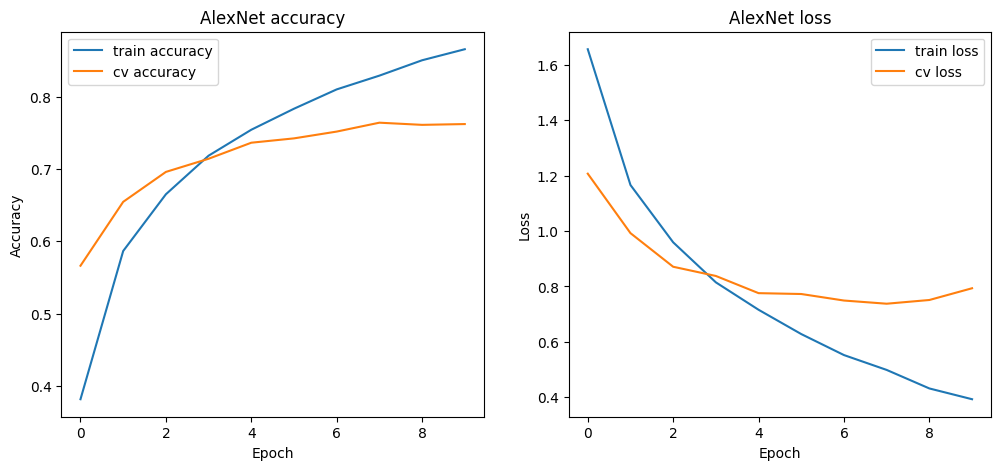

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='cv accuracy')
plt.title('AlexNet accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='cv loss')
plt.title('AlexNet loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Improving AlexNet

As you can see, AlexNet does not work very well on such a small dataset. Recall what you have learned from this class to improve its performance. You can also take a look at the [Dropout technique](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf) and its [implementation in Keras](https://keras.io/layers/core/#dropout). 

In [23]:
improved_alexnet = Sequential([
    Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

improved_alexnet.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_alexnet.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,378,762 (12.89 MB)

 Trainable params: 3,377,866 (12.89 MB)

 Non-trainable params: 896 (3.50 KB)

In [25]:
improved_history = improved_alexnet.fit(
    train_images_norm,
    train_labels_np,
    epochs=10,
    batch_size=64,
    validation_data=(cv_images_norm, cv_labels_np),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 277s 354ms/step - accuracy: 0.6902 - loss: 0.9168 - val_accuracy: 0.6858 - val_loss: 0.9617
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 276s 352ms/step - accuracy: 0.7349 - loss: 0.7958 - val_accuracy: 0.7511 - val_loss: 0.7519
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 279s 357ms/step - accuracy: 0.7622 - loss: 0.7156 - val_accuracy: 0.7635 - val_loss: 0.7335
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 287s 367ms/step - accuracy: 0.7872 - loss: 0.6431 - val_accuracy: 0.7764 - val_loss: 0.6715
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 308s 393ms/step - accuracy: 0.8061 - loss: 0.5879 - val_accuracy: 0.7953 - val_loss: 0.6191
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 520s 665ms/step - accuracy: 0.8212 - loss: 0.5425 - val_accuracy: 0.8131 - val_loss: 0.5850
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 377s 481ms/step - accuracy: 0.8356 - loss: 0.4966 - val_accuracy: 0.7869 - val_loss: 0.6652
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 362s 463ms/step - accuracy: 0.8482 -

In [26]:
improved_train_loss, improved_train_acc = improved_alexnet.evaluate(train_images_norm, train_labels_np, verbose=0)
improved_cv_loss, improved_cv_acc = improved_alexnet.evaluate(cv_images_norm, cv_labels_np, verbose=0)

print("improved train accuracy:", improved_train_acc)
print("improved cv accuracy:", improved_cv_acc)

improved train accuracy: 0.9142000079154968
improved cv accuracy: 0.8360000252723694


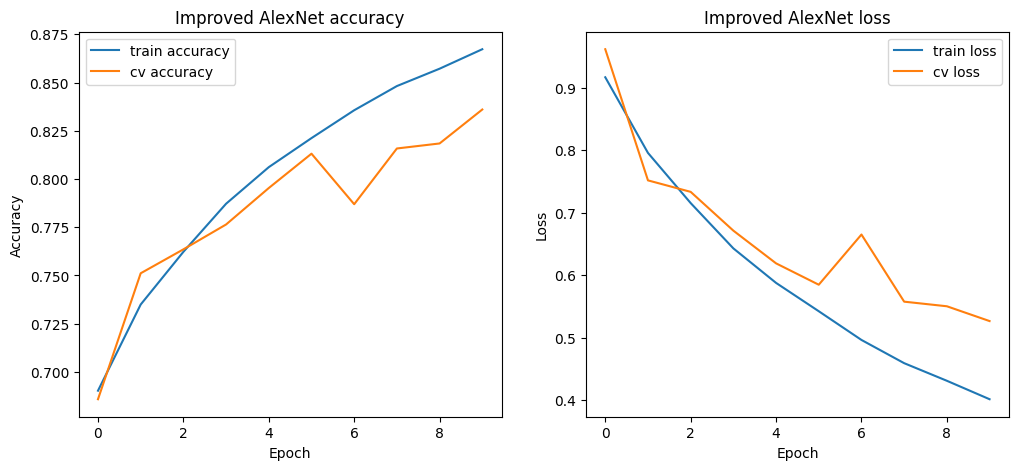

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(improved_history.history['accuracy'], label='train accuracy')
plt.plot(improved_history.history['val_accuracy'], label='cv accuracy')
plt.title('Improved AlexNet accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(improved_history.history['loss'], label='train loss')
plt.plot(improved_history.history['val_loss'], label='cv loss')
plt.title('Improved AlexNet loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()